## Filter datasets to `source == "numina_amc_aime"` (sample 30)

Loads each dataset in `datasets_to_filter`, filters to rows where `source` matches, and takes a random sample of up to **30** rows.


Dataset: RUC-AIBOX/OlymMATH (en-hard)
Splits loaded: ['test']
Total rows: 100
Unique unique_id: 100
Duplicate rows (beyond first occurrence per unique_id): 0


,unique_id,count,pct,rank
0,OlymMATH-HARD-0-EN,1,1.0,1
1,OlymMATH-HARD-1-EN,1,1.0,2
2,OlymMATH-HARD-2-EN,1,1.0,3
3,OlymMATH-HARD-3-EN,1,1.0,4
4,OlymMATH-HARD-4-EN,1,1.0,5
5,OlymMATH-HARD-5-EN,1,1.0,6
6,OlymMATH-HARD-6-EN,1,1.0,7
7,OlymMATH-HARD-7-EN,1,1.0,8
8,OlymMATH-HARD-8-EN,1,1.0,9
9,OlymMATH-HARD-9-EN,1,1.0,10



Repetition distribution (occurrences_per_id -> num_ids):


,occurrences_per_id,num_ids
0,1,100


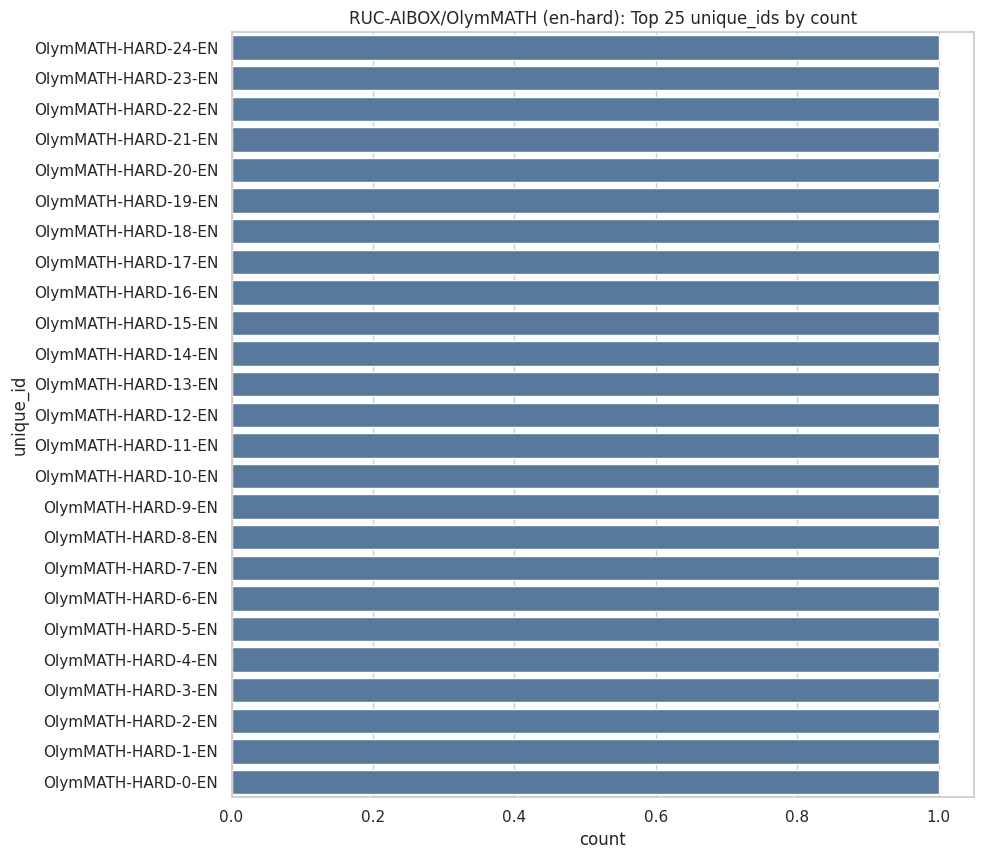

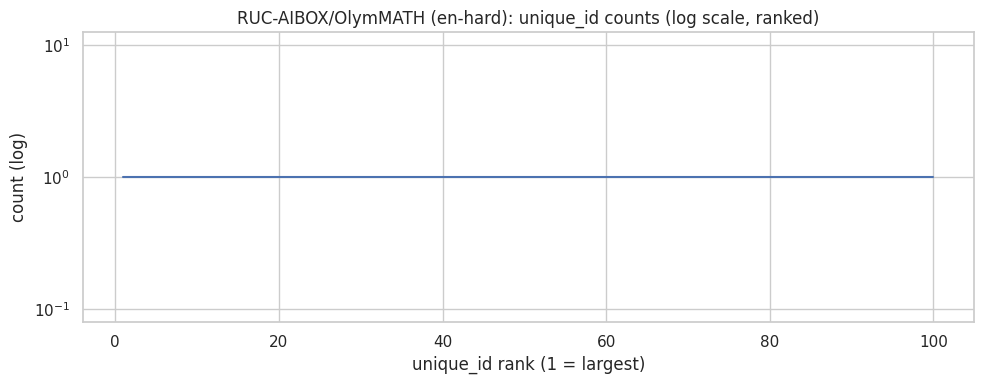

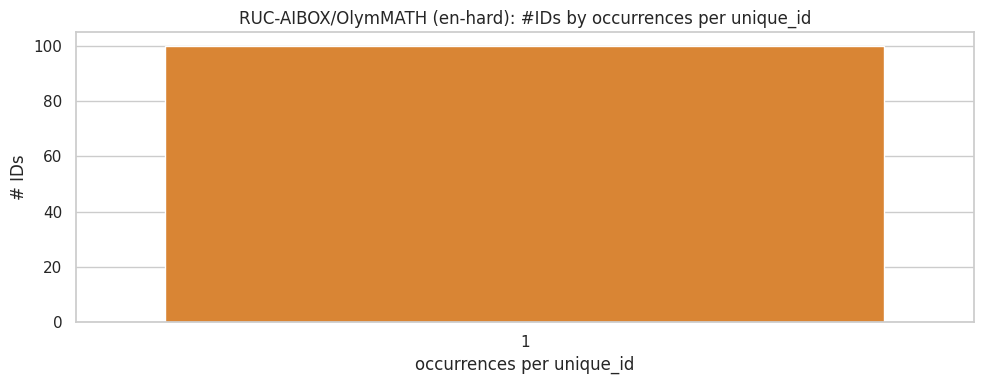

In [6]:
import importlib
import subprocess
import sys
from typing import Optional


def _ensure(import_name: str, pip_name: Optional[str] = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        pkg = pip_name or import_name
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        except Exception as e:
            raise ModuleNotFoundError(
                f"Missing dependency '{import_name}'. Tried to install '{pkg}' via pip but it failed. "
                f"Please install it in this environment (e.g. `pip install {pkg}`) and rerun. Original error: {e}"
            )


_ensure("datasets")
_ensure("pandas")
_ensure("matplotlib")
_ensure("seaborn")

from datasets import load_dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):
        print(x)

DATASET_NAME = "RUC-AIBOX/OlymMATH"
# Required (dataset has multiple configs): one of ['en-hard', 'zh-hard', 'en-easy', 'zh-easy', 'lean']
CONFIG_NAME = "en-hard"
ID_COL = "unique_id"
TOP_N = 25

# Load dataset (handles DatasetDict vs Dataset)
ds = load_dataset(DATASET_NAME, CONFIG_NAME)
if hasattr(ds, "keys"):
    splits = list(ds.keys())
    dsets = [ds[s] for s in splits]
    d_all = pd.concat([d.to_pandas() for d in dsets], ignore_index=True)
else:
    splits = ["(single)"]
    d_all = ds.to_pandas()

if ID_COL not in d_all.columns:
    raise KeyError(
        f"Expected column '{ID_COL}' not found. Available columns: {list(d_all.columns)}"
    )

# Basic stats by unique_id
n_rows = len(d_all)
id_counts = (
    d_all[ID_COL]
    .fillna("(missing)")
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis(ID_COL)
    .reset_index(name="count")
)
id_counts["pct"] = id_counts["count"] / n_rows * 100
id_counts["rank"] = range(1, len(id_counts) + 1)

n_unique = id_counts[ID_COL].nunique()
dup_rows = int((id_counts["count"] - 1).clip(lower=0).sum())

print(f"Dataset: {DATASET_NAME} ({CONFIG_NAME})")
print(f"Splits loaded: {splits}")
print(f"Total rows: {n_rows}")
print(f"Unique {ID_COL}: {n_unique}")
print(f"Duplicate rows (beyond first occurrence per {ID_COL}): {dup_rows}")

display(id_counts.head(50))

# Distribution: how many IDs appear 1x / 2x / 3x ...
rep_dist = (
    id_counts["count"]
    .value_counts()
    .sort_index()
    .rename_axis("occurrences_per_id")
    .reset_index(name="num_ids")
)
print("\nRepetition distribution (occurrences_per_id -> num_ids):")
display(rep_dist.head(50))

# Visualizations
sns.set_theme(style="whitegrid")

# 1) Top-N IDs by count
plot_df = id_counts.head(TOP_N).iloc[::-1]
plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
ax = sns.barplot(data=plot_df, x="count", y=ID_COL, color="#4C78A8")
ax.set_title(f"{DATASET_NAME} ({CONFIG_NAME}): Top {min(TOP_N, len(id_counts))} {ID_COL}s by count")
ax.set_xlabel("count")
ax.set_ylabel(ID_COL)
plt.tight_layout()
plt.show()

# 2) Long-tail (log scale)
plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=id_counts, x="rank", y="count")
ax.set_yscale("log")
ax.set_title(f"{DATASET_NAME} ({CONFIG_NAME}): {ID_COL} counts (log scale, ranked)")
ax.set_xlabel(f"{ID_COL} rank (1 = largest)")
ax.set_ylabel("count (log)")
plt.tight_layout()
plt.show()

# 3) Histogram of occurrences per ID
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=rep_dist.head(50), x="occurrences_per_id", y="num_ids", color="#F58518")
ax.set_title(f"{DATASET_NAME} ({CONFIG_NAME}): #IDs by occurrences per {ID_COL}")
ax.set_xlabel(f"occurrences per {ID_COL}")
ax.set_ylabel("# IDs")
plt.tight_layout()
plt.show()

# Optional: split-wise breakdown (if multiple splits exist)
if hasattr(ds, "keys") and len(splits) > 1:
    by_split = []
    for s in splits:
        tmp = ds[s].to_pandas()
        tmp[ID_COL] = tmp[ID_COL].fillna("(missing)").astype(str)
        c = tmp[ID_COL].value_counts().rename_axis(ID_COL).reset_index(name="count")
        c["split"] = s
        by_split.append(c)
    by_split = pd.concat(by_split, ignore_index=True)
    display(by_split.pivot_table(index=ID_COL, columns="split", values="count", fill_value=0))


## PRIME_RL/EURUS — source statistics

This section summarizes:
- **What sources the dataset is from** (unique values in the `source` column)
- **How many examples per source** (counts + percentages)
- **Visualizations** (top sources + long-tail distribution)


In [7]:
import importlib
import subprocess
import sys
from pathlib import Path
from typing import Optional

import pandas as pd

try:
    from IPython.display import display  # type: ignore
except Exception:

    def display(x):
        print(x)


def _ensure(import_name: str, pip_name: Optional[str] = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


def _norm_answer(x) -> Optional[str]:
    if x is None:
        return None
    s = str(x).strip()
    return s if s else None


_ensure("datasets")
_ensure("pandas")
_ensure("pyarrow")  # pandas parquet engine

from datasets import concatenate_datasets, load_dataset

HF_NAME = "RUC-AIBOX/OlymMATH"
# This dataset requires a config name. We'll load the HARD configs and filter by unique_id prefix/suffix.
CONFIG_NAMES = ["en-hard", "zh-hard"]
ID_COL = "unique_id"
ID_PREFIX = "OlymMATH-HARD"
ID_SUFFIX = "-EN"
SAMPLE_N = 30
SEED = 0

# Write under `benchmarks/filtered_samples/` if cwd is repo-root; otherwise under `./filtered_samples/`.
BASE_DIR = Path(".")
if (BASE_DIR / "benchmarks" / "filter_benchmark_still.ipynb").exists():
    OUT_DIR = BASE_DIR / "benchmarks" / "filtered_samples"
else:
    OUT_DIR = BASE_DIR / "filtered_samples"
OUT_DIR.mkdir(parents=True, exist_ok=True)

parts = []
loaded = []
for cfg in CONFIG_NAMES:
    ds = load_dataset(HF_NAME, cfg)
    splits = list(ds.keys()) if hasattr(ds, "keys") else ["(single)"]

    for s in splits:
        d = ds[s] if s != "(single)" else ds

        def _match_uid(ex, p=ID_PREFIX, suf=ID_SUFFIX):
            uid = str(ex.get(ID_COL) or "")
            return uid.startswith(p) and uid.endswith(suf)

        d_match = d.filter(_match_uid)
        if len(d_match) == 0:
            continue
        if "config" not in d_match.column_names:
            d_match = d_match.add_column("config", [cfg] * len(d_match))
        if "split" not in d_match.column_names:
            d_match = d_match.add_column("split", [s] * len(d_match))
        parts.append(d_match)
        loaded.append((cfg, s, len(d_match)))

if not parts:
    summary_df = pd.DataFrame(
        [
            {
                "dataset": HF_NAME,
                "configs": CONFIG_NAMES,
                "id_col": ID_COL,
                "id_prefix": ID_PREFIX,
                "matches": 0,
                "sampled": 0,
                "status": "ok (no matches)",
            }
        ]
    )
    display(summary_df)
else:
    d_all = concatenate_datasets(parts) if len(parts) > 1 else parts[0]
    n_match = len(d_all)
    d30 = d_all.shuffle(seed=SEED).select(range(min(SAMPLE_N, n_match)))

    summary_df = pd.DataFrame(
        [
            {
                "dataset": HF_NAME,
                "configs": CONFIG_NAMES,
                "loaded_parts": loaded,
                "id_col": ID_COL,
                "id_prefix": ID_PREFIX,
                "matches": n_match,
                "sampled": len(d30),
                "status": "ok",
            }
        ]
    )
    display(summary_df)

    out_stem = f"talzoomanzoo__STILL__{ID_PREFIX}{ID_SUFFIX}__sample30"
    out_parquet = OUT_DIR / f"{out_stem}.parquet"

    df30 = d30.to_pandas()
    if "problem" not in df30.columns:
        raise KeyError(
            f"Expected column 'problem' not found. Available columns: {list(df30.columns)}"
        )
    if "answer" not in df30.columns:
        raise KeyError(
            f"Expected column 'answer' not found. Available columns: {list(df30.columns)}"
        )

    # Build prompts to match `talzoomanzoo/aime26` schema: columns ['data_source', 'prompt', 'answer']
    def _extract_system_msg_from_prompt_cell(prompt_val) -> str:
        v = prompt_val
        if hasattr(v, "tolist") and not isinstance(v, (str, bytes, dict, list, tuple)):
            try:
                v = v.tolist()
            except Exception:
                pass

        if isinstance(v, dict):
            v = [v]
        elif isinstance(v, tuple):
            v = list(v)

        if not isinstance(v, list) or not v:
            raise TypeError(f"prompt cell is not list-like (got {type(prompt_val)})")

        first = v[0]
        if isinstance(first, dict) and "content" in first:
            return str(first["content"])
        raise TypeError(f"unexpected prompt element type/shape: {type(first)}")

    def _try_load_system_msg(template_parquet: Path) -> str:
        df = pd.read_parquet(template_parquet)
        if "prompt" not in df.columns:
            raise KeyError(f"{template_parquet} missing 'prompt' column")
        return _extract_system_msg_from_prompt_cell(df.iloc[0]["prompt"])

    template_candidates = [
        OUT_DIR / "GAIR__LIMR__math__sample30__aime26_prompt.parquet",
        OUT_DIR / "math-ai__aime26__eurus_prompt.parquet",
        OUT_DIR / "math-ai__aime26__limr_prompt.parquet",
        OUT_DIR / "math-ai__aime26__still_prompt.parquet",
        Path("benchmarks") / "filtered_samples" / "GAIR__LIMR__math__sample30__aime26_prompt.parquet",
        Path("benchmarks") / "filtered_samples" / "math-ai__aime26__eurus_prompt.parquet",
        Path("benchmarks") / "filtered_samples" / "math-ai__aime26__limr_prompt.parquet",
        Path("benchmarks") / "filtered_samples" / "math-ai__aime26__still_prompt.parquet",
    ]

    system_msg = None
    for cand in template_candidates:
        if not cand.exists():
            continue
        try:
            system_msg = _try_load_system_msg(cand)
            break
        except Exception as e:
            print(f"Skipping template {cand} (can't extract system msg): {e}")

    if system_msg is None:
        system_msg = "You are a helpful assistant."
        print("Warning: couldn't find a chat-style template parquet; using fallback system message.")

    problems = df30["problem"].tolist()
    answers = [_norm_answer(a) for a in df30["answer"].tolist()]

    df_out = pd.DataFrame(
        {
            "data_source": ["still"] * len(df30),
            "prompt": [
                [
                    {"role": "system", "content": system_msg},
                    {
                        "role": "user",
                        "content": str(p).rstrip()
                        + "\n\nPresent the answer in LaTex format: \\boxed{Your answer}",
                    },
                ]
                for p in problems
            ],
            "answer": answers,
        }
    )

    df_out.to_parquet(out_parquet, index=False)
    print(f"Wrote: {out_parquet}")
    display(df_out.head(10))

    # --- Upload to Hugging Face Hub ---
    _ensure("huggingface_hub")
    import os

    from huggingface_hub import HfApi, HfFolder

    HF_REPO_ID = "talzoomanzoo/STILL"
    HF_REPO_TYPE = "dataset"

    token = HfFolder.get_token() or os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_TOKEN")
    if not token:
        raise RuntimeError(
            "Hugging Face token not found. Run `huggingface-cli login` in this environment, "
            "or set `HF_TOKEN` (or `HUGGINGFACE_TOKEN`) and re-run the cell."
        )

    api = HfApi(token=token)
    api.create_repo(repo_id=HF_REPO_ID, repo_type=HF_REPO_TYPE, exist_ok=True)

    # Keep repo clean: remove other parquet files so load_dataset() won't silently include extras.
    existing_files = api.list_repo_files(repo_id=HF_REPO_ID, repo_type=HF_REPO_TYPE)
    for f in existing_files:
        if f.endswith(".parquet") and f != out_parquet.name:
            api.delete_file(
                path_in_repo=f,
                repo_id=HF_REPO_ID,
                repo_type=HF_REPO_TYPE,
                commit_message=f"Remove {f} (keep only {out_parquet.name})",
            )
            print(f"Deleted from repo: {f}")

    uploaded_url = api.upload_file(
        path_or_fileobj=str(out_parquet),
        path_in_repo=out_parquet.name,
        repo_id=HF_REPO_ID,
        repo_type=HF_REPO_TYPE,
        commit_message=f"Add {out_parquet.name}",
    )
    print(f"Uploaded to: {uploaded_url}")


,dataset,configs,loaded_parts,id_col,id_prefix,matches,sampled,status
0,RUC-AIBOX/OlymMATH,"[en-hard, zh-hard]","[(en-hard, test, 100)]",unique_id,OlymMATH-HARD,100,30,ok


Wrote: filtered_samples/talzoomanzoo__STILL__OlymMATH-HARD-EN__sample30.parquet


,data_source,prompt,answer
0,still,"[{'role': 'system', 'content': ' When tackling...",0.84
1,still,"[{'role': 'system', 'content': ' When tackling...",\frac{2318}{5}
2,still,"[{'role': 'system', 'content': ' When tackling...",12 \times 2^{2022} - 24
3,still,"[{'role': 'system', 'content': ' When tackling...",\frac{\sqrt{51}}{6}
4,still,"[{'role': 'system', 'content': ' When tackling...",48
5,still,"[{'role': 'system', 'content': ' When tackling...",1296
6,still,"[{'role': 'system', 'content': ' When tackling...",31
7,still,"[{'role': 'system', 'content': ' When tackling...",\frac{16\sqrt{2}}{9}
8,still,"[{'role': 'system', 'content': ' When tackling...",4650
9,still,"[{'role': 'system', 'content': ' When tackling...",1581330


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (1 / 1)                : 100%|██████████| 10.3kB / 10.3kB,   ???B/s  





Processing Files (1 / 1)                : 100%|██████████| 10.3kB / 10.3kB,  0.00B/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ..._OlymMATH-HARD-EN__sample30.parquet: 100%|██████████| 10.3kB / 10.3kB            
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded to: https://huggingface.co/datasets/talzoomanzoo/STILL/blob/main/talzoomanzoo__STILL__OlymMATH-HARD-EN__sample30.parquet




Processing Files (1 / 1)                : 100%|██████████| 11.6kB / 11.6kB,   ???B/s  



Processing Files (1 / 1)                : 100%|██████████| 17.7kB / 17.7kB,   ???B/s  


In [8]:
import os
from pathlib import Path
from typing import Optional

import pandas as pd

# Ensure dependencies (safe even if already installed)
import importlib
import subprocess
import sys


def _ensure(import_name: str, pip_name: Optional[str] = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


def _norm_answer(x) -> Optional[str]:
    if x is None:
        return None
    s = str(x).strip()
    return s if s else None


_ensure("datasets")
_ensure("pandas")
_ensure("pyarrow")

from datasets import concatenate_datasets, load_dataset

# Avoid hf_transfer requirement if enabled in env
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

try:
    from IPython.display import display  # type: ignore
except Exception:

    def display(x):
        print(x)


# ----- Read system prompt template from an existing parquet with `prompt` -----
# Resolve `filtered_samples/` robustly regardless of whether cwd is repo-root or `benchmarks/`.
FILTERED_DIR_CANDIDATES = [Path("filtered_samples"), Path("benchmarks") / "filtered_samples"]
FILTERED_DIR = next((p for p in FILTERED_DIR_CANDIDATES if p.exists()), FILTERED_DIR_CANDIDATES[0])
FILTERED_DIR.mkdir(parents=True, exist_ok=True)

# Use the Eurus 30-sample parquet as the prompt template source (it contains `prompt`).
TEMPLATE_PARQUET_NAME = "PRIME-RL__Eurus-2-RL-Data__numina_amc_aime__sample30.parquet"
TEMPLATE_PARQUET_CANDIDATES = [
    FILTERED_DIR / TEMPLATE_PARQUET_NAME,
    Path("benchmarks") / "filtered_samples" / TEMPLATE_PARQUET_NAME,
]
TEMPLATE_PARQUET = next((p for p in TEMPLATE_PARQUET_CANDIDATES if p.exists()), None)
if TEMPLATE_PARQUET is None:
    raise FileNotFoundError(
        "Can't find a prompt-template parquet. Expected one of: "
        + ", ".join(str(p) for p in TEMPLATE_PARQUET_CANDIDATES)
        + ". Run the Eurus sampling cell first."
    )

def _extract_system_msg_from_prompt_cell(prompt_val) -> str:
    v = prompt_val
    if hasattr(v, "tolist") and not isinstance(v, (str, bytes, dict, list, tuple)):
        try:
            v = v.tolist()
        except Exception:
            pass

    if isinstance(v, dict):
        v = [v]
    elif isinstance(v, tuple):
        v = list(v)

    if not isinstance(v, list) or not v:
        raise TypeError(f"prompt cell is not list-like (got {type(prompt_val)})")

    first = v[0]
    if isinstance(first, dict) and "content" in first:
        return str(first["content"])
    raise TypeError(f"unexpected prompt element type/shape: {type(first)}")


def _try_load_system_msg(template_parquet: Path) -> str:
    df = pd.read_parquet(template_parquet)
    if "prompt" not in df.columns:
        raise KeyError(f"{template_parquet} missing 'prompt' column")
    return _extract_system_msg_from_prompt_cell(df.iloc[0]["prompt"])


template_candidates = [
    FILTERED_DIR / "GAIR__LIMR__math__sample30__aime26_prompt.parquet",
    FILTERED_DIR / "math-ai__aime26__eurus_prompt.parquet",
    FILTERED_DIR / "math-ai__aime26__limr_prompt.parquet",
    FILTERED_DIR / "math-ai__aime26__still_prompt.parquet",
    Path("benchmarks") / "filtered_samples" / "GAIR__LIMR__math__sample30__aime26_prompt.parquet",
    Path("benchmarks") / "filtered_samples" / "math-ai__aime26__eurus_prompt.parquet",
    Path("benchmarks") / "filtered_samples" / "math-ai__aime26__limr_prompt.parquet",
    Path("benchmarks") / "filtered_samples" / "math-ai__aime26__still_prompt.parquet",
]

EURUS_SYSTEM_MSG = None
for cand in template_candidates:
    if not cand.exists():
        continue
    try:
        EURUS_SYSTEM_MSG = _try_load_system_msg(cand)
        break
    except Exception as e:
        print(f"Skipping template {cand} (can't extract system msg): {e}")

if EURUS_SYSTEM_MSG is None:
    EURUS_SYSTEM_MSG = "You are a helpful assistant."
    print("Warning: couldn't find a chat-style template parquet; using fallback system message.")

# ----- Load AIME 2026 dataset and format prompts -----
AIME_NAME = "math-ai/aime26"
DATA_SOURCE = "aime26"


def _pick_problem_col(cols: list[str]) -> str:
    for c in ["problem", "question", "prompt", "statement"]:
        if c in cols:
            return c
    raise KeyError(f"No problem-like column found. Available columns: {cols}")


def _pick_answer_col(cols: list[str]) -> str:
    for c in ["answer", "final_answer", "target", "solution"]:
        if c in cols:
            return c
    raise KeyError(f"No answer-like column found. Available columns: {cols}")


aime = load_dataset(AIME_NAME)
if hasattr(aime, "keys"):
    splits = list(aime.keys())
    parts = [aime[s] for s in splits]
    aime_all = concatenate_datasets(parts) if len(parts) > 1 else parts[0]
else:
    splits = ["(single)"]
    aime_all = aime

problem_col = _pick_problem_col(aime_all.column_names)
answer_col = _pick_answer_col(aime_all.column_names)

rows = []
for ex in aime_all:
    problem = ex.get(problem_col)
    if problem is None:
        continue
    user_content = (
        str(problem).rstrip()
        + "\n\nPresent the answer in LaTex format: \\boxed{Your answer}"
    )
    rows.append(
        {
            "data_source": DATA_SOURCE,
            "prompt": [
                {"role": "system", "content": EURUS_SYSTEM_MSG},
                {"role": "user", "content": user_content},
            ],
            "answer": _norm_answer(ex.get(answer_col)),
        }
    )

aime_df = pd.DataFrame(rows)
print(f"Loaded {AIME_NAME} splits={splits} rows={len(aime_all)}")
print(f"Formatted rows={len(aime_df)}")

OUT_DIR = FILTERED_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_parquet = OUT_DIR / "math-ai__aime26__still_prompt.parquet"
aime_df.to_parquet(out_parquet, index=False)
print(f"Wrote: {out_parquet}")

display(aime_df.head(3))

# Optional upload (only if token present)
_ensure("huggingface_hub")
from huggingface_hub import HfApi, HfFolder

token = HfFolder.get_token() or os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_TOKEN")
if token:
    api = HfApi(token=token)

    # 1) Upload into your combined repo (same as Eurus pipeline)
    repo_id = "talzoomanzoo/STILL-amc-aime"
    api.create_repo(repo_id=repo_id, repo_type="dataset", exist_ok=True)
    url = api.upload_file(
        path_or_fileobj=str(out_parquet),
        path_in_repo=out_parquet.name,
        repo_id=repo_id,
        repo_type="dataset",
        commit_message=f"Add {out_parquet.name} (aime26)",
    )
    print(f"Uploaded to: {url}")

    # 2) Also upload as its own dataset repo
    repo_id2 = "talzoomanzoo/aime26"
    api.create_repo(repo_id=repo_id2, repo_type="dataset", exist_ok=True)
    url2 = api.upload_file(
        path_or_fileobj=str(out_parquet),
        path_in_repo=out_parquet.name,
        repo_id=repo_id2,
        repo_type="dataset",
        commit_message=f"Add {out_parquet.name}",
    )
    print(f"Uploaded to: {url2}")
else:
    print(
        "No Hugging Face token found (HF_TOKEN/HUGGINGFACE_TOKEN or huggingface-cli login). "
        "Skipping upload."
    )


Loaded math-ai/aime26 splits=['test'] rows=30
Formatted rows=30
Wrote: filtered_samples/math-ai__aime26__still_prompt.parquet


,data_source,prompt,answer
0,aime26,"[{'role': 'system', 'content': ' When tackling...",277
1,aime26,"[{'role': 'system', 'content': ' When tackling...",62
2,aime26,"[{'role': 'system', 'content': ' When tackling...",79


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            
Processing Files (1 / 1)                : 100%|██████████| 11.6kB / 11.6kB,  0.00B/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...th-ai__aime26__still_prompt.parquet: 100%|██████████| 11.6kB / 11.6kB            
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded to: https://huggingface.co/datasets/talzoomanzoo/STILL-amc-aime/blob/main/math-ai__aime26__still_prompt.parquet


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (1 / 1)                : 100%|██████████| 11.6kB / 11.6kB,   ???B/s  
Processing Files (1 / 1)                : 100%|██████████| 11.6kB / 11.6kB,  0.00B/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...th-ai__aime26__still_prompt.parquet: 100%|██████████| 11.6kB / 11.6kB            
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded to: https://huggingface.co/datasets/talzoomanzoo/aime26/blob/main/math-ai__aime26__still_prompt.parquet


## Combine HF datasets: `talzoomanzoo/aime26` + `talzoomanzoo/Eurus-2-RL-Data-amc-aime`

Adds a `member` column:
- `talzoomanzoo/aime26` → `member = 0`
- `talzoomanzoo/Eurus-2-RL-Data-amc-aime` → `member = 1`


In [9]:
import os
from pathlib import Path

import pandas as pd

# avoid requiring hf_transfer if set in environment
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

from datasets import Dataset, DatasetDict, concatenate_datasets, load_dataset

AIME_REPO = "math-ai/aime26"  # raw dataset: columns like ['problem', 'answer', ...]
STILL_REPO = "talzoomanzoo/STILL"  # formatted dataset: columns ['data_source', 'prompt', 'answer']


def _norm_answer(x):
    if x is None:
        return None
    s = str(x).strip()
    return s if s else None


def _pick_split(ds: DatasetDict | Dataset) -> Dataset:
    if isinstance(ds, DatasetDict):
        split = "train" if "train" in ds else list(ds.keys())[0]
        return ds[split]
    return ds


def _pick_problem_col(cols: list[str]) -> str:
    for c in ["problem", "question", "prompt", "statement", "text"]:
        if c in cols:
            return c
    raise KeyError(f"No problem-like column found. Available columns: {cols}")


def _pick_answer_col(cols: list[str]) -> str:
    for c in ["answer", "final_answer", "target", "solution"]:
        if c in cols:
            return c
    raise KeyError(f"No answer-like column found. Available columns: {cols}")


# Load STILL (already prompt-formatted)
still = _pick_split(load_dataset(STILL_REPO))
need_cols = {"data_source", "prompt", "answer"}
missing = sorted(need_cols - set(still.column_names))
if missing:
    raise KeyError(f"still missing expected columns {missing}. Has: {still.column_names}")

# Use STILL's system message as the template for AIME formatting
still_ex0 = still[0]
still_prompt0 = still_ex0.get("prompt")
if not (isinstance(still_prompt0, list) and len(still_prompt0) > 0):
    raise TypeError(f"Unexpected still prompt type/shape: {type(still_prompt0)}")
system_msg = still_prompt0[0]["content"]

# Load raw AIME and format into the same prompt schema
raw_aime = _pick_split(load_dataset(AIME_REPO))
problem_col = _pick_problem_col(raw_aime.column_names)
answer_col = _pick_answer_col(raw_aime.column_names)

rows = []
for ex in raw_aime:
    prob = ex.get(problem_col)
    if prob is None:
        continue
    user_content = str(prob).rstrip() + "\n\nPresent the answer in LaTex format: \\boxed{Your answer}"
    rows.append(
        {
            "data_source": "aime26",
            "prompt": [
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_content},
            ],
            "answer": _norm_answer(ex.get(answer_col)),
        }
    )

aime_df = pd.DataFrame(rows)
aime = Dataset.from_pandas(aime_df, preserve_index=False)

# Add member column
aime = aime.add_column("member", [0] * len(aime))
still = still.add_column("member", [1] * len(still))

combined = concatenate_datasets([aime, still])
print("aime rows:", len(aime))
print("still rows:", len(still))
print("combined rows:", len(combined))
print("combined columns:", combined.column_names)

# Save under benchmarks/
BASE_DIR = Path(".")
if not (BASE_DIR / "filter_benchmark.ipynb").exists():
    BASE_DIR = Path("benchmarks")

OUT_DIR = BASE_DIR / "filtered_samples"
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_parquet = OUT_DIR / "talzoomanzoo__aime26_plus_still_amc_aime__with_member.parquet"
df = combined.to_pandas()
df.to_parquet(out_parquet, index=False)
print("Wrote:", out_parquet)

display(df.head(5))

# Upload to Hugging Face as `talzoomanzoo/still_member`
import importlib
import subprocess
import sys


def _ensure(import_name: str) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", import_name])


_ensure("huggingface_hub")

from huggingface_hub import HfApi, HfFolder

HF_REPO_ID = "talzoomanzoo/still_member"
HF_REPO_TYPE = "dataset"

token = HfFolder.get_token() or os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_TOKEN")
if not token:
    raise RuntimeError(
        "Hugging Face token not found. Run `huggingface-cli login` in this environment, "
        "or set `HF_TOKEN` (or `HUGGINGFACE_TOKEN`) and re-run the cell."
    )

api = HfApi(token=token)
api.create_repo(repo_id=HF_REPO_ID, repo_type=HF_REPO_TYPE, exist_ok=True)

# Keep repo clean: remove other parquet files so load_dataset() won't silently include extras.
existing_files = api.list_repo_files(repo_id=HF_REPO_ID, repo_type=HF_REPO_TYPE)
for f in existing_files:
    if f.endswith(".parquet") and f != out_parquet.name:
        api.delete_file(
            path_in_repo=f,
            repo_id=HF_REPO_ID,
            repo_type=HF_REPO_TYPE,
            commit_message=f"Remove {f} (keep only {out_parquet.name})",
        )
        print(f"Deleted from repo: {f}")

url = api.upload_file(
    path_or_fileobj=str(out_parquet),
    path_in_repo=out_parquet.name,
    repo_id=HF_REPO_ID,
    repo_type=HF_REPO_TYPE,
    commit_message=f"Add {out_parquet.name}",
)
print(f"Uploaded to: {url}")


aime rows: 30
still rows: 30
combined rows: 60
combined columns: ['data_source', 'prompt', 'answer', 'member']
Wrote: filtered_samples/talzoomanzoo__aime26_plus_still_amc_aime__with_member.parquet


,data_source,prompt,answer,member
0,aime26,[{'content': ' When tackling complex reasoning...,277,0
1,aime26,[{'content': ' When tackling complex reasoning...,62,0
2,aime26,[{'content': ' When tackling complex reasoning...,79,0
3,aime26,[{'content': ' When tackling complex reasoning...,70,0
4,aime26,[{'content': ' When tackling complex reasoning...,65,0


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            
Processing Files (1 / 1)                : 100%|██████████| 17.7kB / 17.7kB,  0.00B/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...still_amc_aime__with_member.parquet: 100%|██████████| 17.7kB / 17.7kB            
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded to: https://huggingface.co/datasets/talzoomanzoo/still_member/blob/main/talzoomanzoo__aime26_plus_still_amc_aime__with_member.parquet
